# Keyence + YX1 pipeline failure dashboard

This dashboard is generated from `pipeline_audit.xlsx`. It separates:

- **Confirmed clean:** terminal product exists and the latest back-half run finished cleanly.
- **Terminal product present:** a parquet exists, but the latest run may have failed or be unconfirmed.
- **Stage completion:** validated per-well shards or the appropriate merged terminal artifact.

Run `refresh_pipeline_audit.py` to rebuild the workbook and regenerate this notebook.

In [1]:
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
WORKBOOK = Path("pipeline_audit.xlsx")
audit = pd.read_excel(WORKBOOK, sheet_name="Dataset Audit")
progression = pd.read_excel(WORKBOOK, sheet_name="Progression")
summary = pd.read_excel(WORKBOOK, sheet_name="Executive Summary")
taxonomy = pd.read_excel(WORKBOOK, sheet_name="Failure Taxonomy")
recovery = pd.read_excel(WORKBOOK, sheet_name="Recovery Priorities")
display(summary)

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## Executive progress

,datasets,confirmed_clean,terminal_present,confirmed_fraction,terminal_fraction
scope,,,,,
Keyence,97,46,47,0.474227,0.484536
YX1,65,34,41,0.523077,0.630769


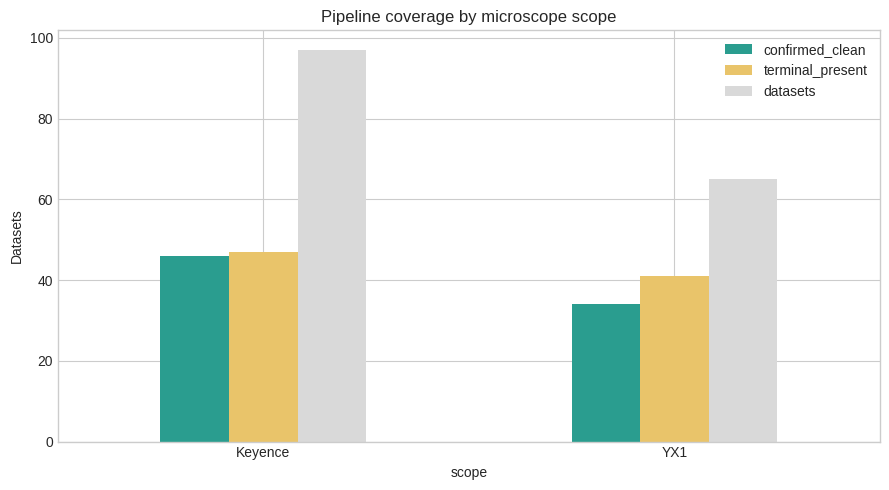

In [ ]:
scope = audit.groupby("scope").agg(
    datasets=("experiment_id", "size"),
    confirmed_clean=("confirmed_clean_latest_run", "sum"),
    terminal_present=("terminal_product_present", "sum"),
)
scope["confirmed_fraction"] = scope["confirmed_clean"] / scope["datasets"]
scope["terminal_fraction"] = scope["terminal_present"] / scope["datasets"]
display(scope)

ax = scope[["confirmed_clean", "terminal_present", "datasets"]].plot(
    kind="bar", figsize=(9, 5), color=["#2A9D8F", "#E9C46A", "#D9D9D9"]
)
ax.set_ylabel("Datasets")
ax.set_title("Pipeline coverage by microscope scope")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Monotonic data funnel

A dataset reaches a gate only when that gate and every preceding gate are complete.
This is the appropriate progression view for a branching DAG.

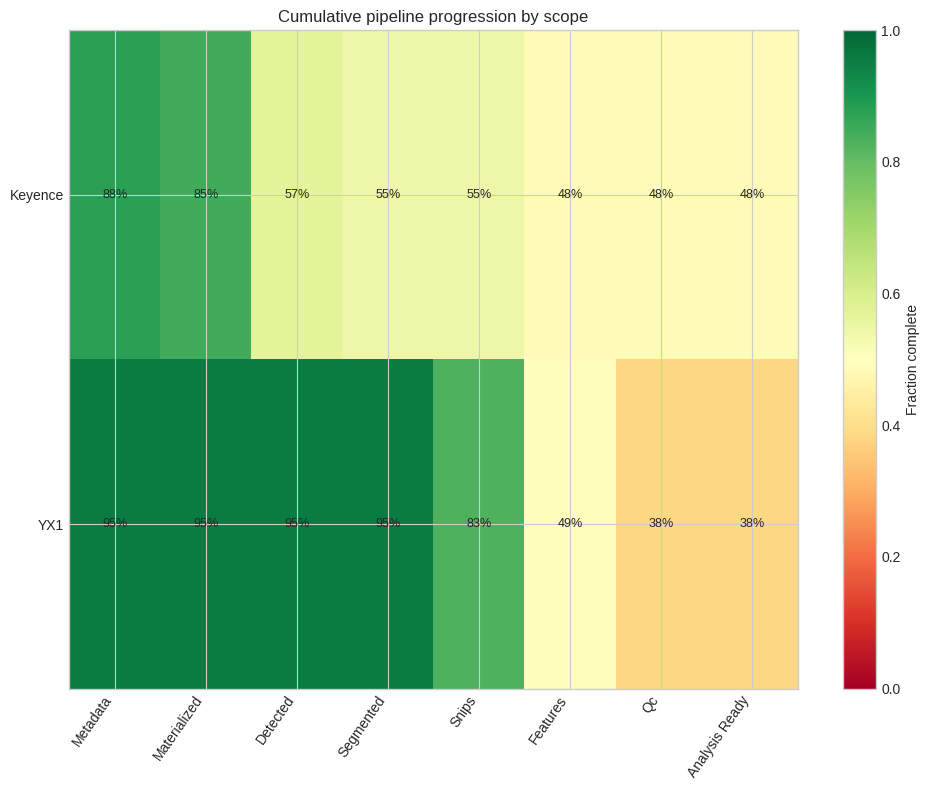

In [ ]:
gate_cols = [c for c in progression.columns if c.startswith("gate_reached_")]
gate_labels = [c.removeprefix("gate_reached_").replace("_", " ").title() for c in gate_cols]
gate_by_scope = progression.groupby("scope")[gate_cols].mean().T
gate_by_scope.index = gate_labels

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(gate_by_scope.T.values, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
ax.set_yticks(range(len(gate_by_scope.columns)), gate_by_scope.columns)
ax.set_xticks(range(len(gate_by_scope.index)), gate_by_scope.index, rotation=55, ha="right")
for y in range(gate_by_scope.shape[1]):
    for x in range(gate_by_scope.shape[0]):
        ax.text(x, y, f"{gate_by_scope.iloc[x, y]:.0%}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=ax, label="Fraction complete")
ax.set_title("Cumulative pipeline progression by scope")
plt.tight_layout()
plt.show()

### Raw artifact availability

This diagnostic is intentionally **not** a funnel. Independent branches and stale products can
make a later artifact present while another branch is incomplete.

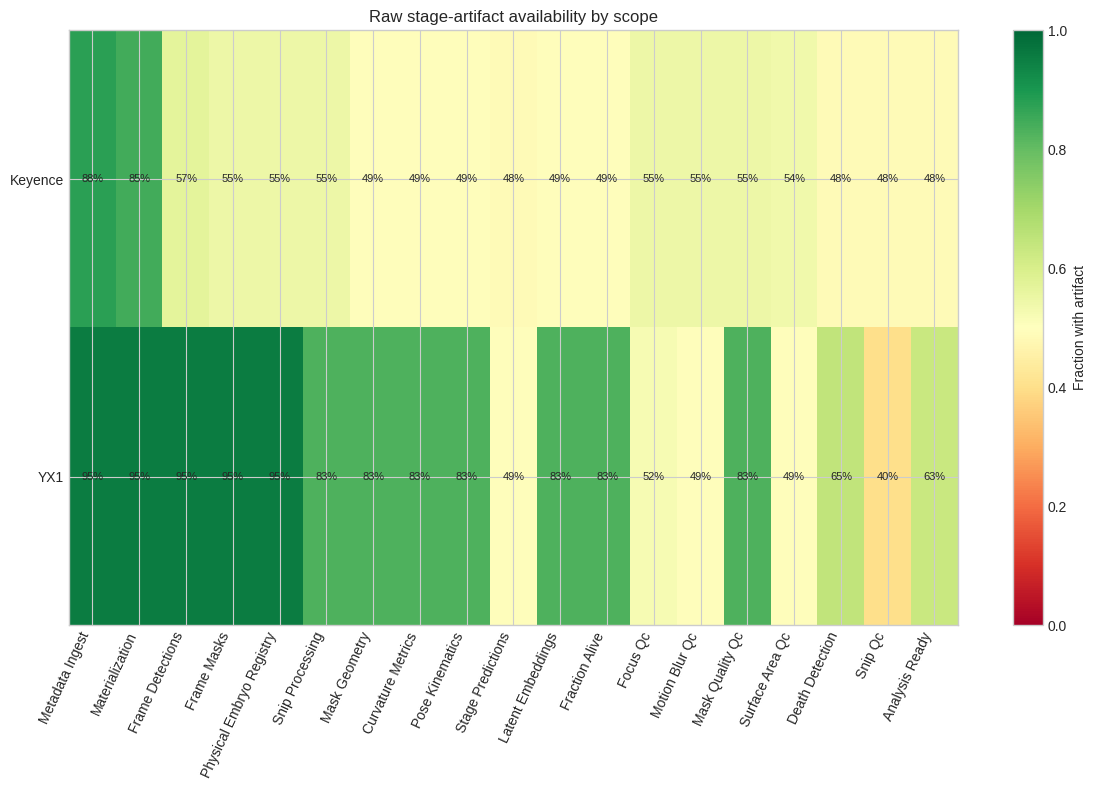

In [ ]:
stage_cols = [c for c in audit.columns if c.startswith("stage_")]
stage_labels = [c.removeprefix("stage_").replace("_", " ").title() for c in stage_cols]
stage_by_scope = audit.groupby("scope")[stage_cols].mean().T
stage_by_scope.index = stage_labels

fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(stage_by_scope.T.values, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
ax.set_yticks(range(len(stage_by_scope.columns)), stage_by_scope.columns)
ax.set_xticks(range(len(stage_by_scope.index)), stage_by_scope.index, rotation=65, ha="right")
for y in range(stage_by_scope.shape[1]):
    for x in range(stage_by_scope.shape[0]):
        ax.text(x, y, f"{stage_by_scope.iloc[x, y]:.0%}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Fraction with artifact")
ax.set_title("Raw stage-artifact availability by scope")
plt.tight_layout()
plt.show()

## Failure modes

scope,Keyence,YX1
failure_category,,
Not previously attempted,27,0
Materialization geometry,10,0
Input eligibility,4,0
Acquisition reconciliation,1,0
Source corruption,1,0
Unclassified runtime failure,1,0
Workflow state,1,0
Artifact compatibility,0,11
Filesystem permissions,0,8


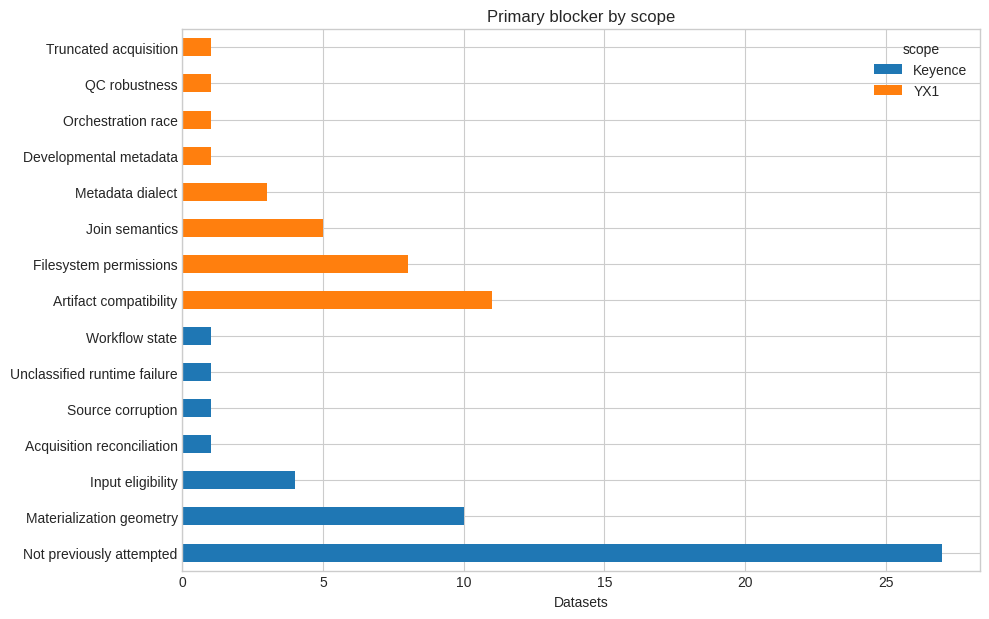

In [ ]:
failure_counts = (
    audit.loc[audit["confirmed_clean_latest_run"] == 0]
    .groupby(["failure_category", "scope"])
    .size()
    .unstack(fill_value=0)
    .sort_values(by=list(audit["scope"].unique()), ascending=False)
)
display(failure_counts)
ax = failure_counts.plot(kind="barh", stacked=True, figsize=(10, max(5, len(failure_counts) * 0.42)))
ax.set_xlabel("Datasets")
ax.set_ylabel("")
ax.set_title("Primary blocker by scope")
plt.tight_layout()
plt.show()

## Path to 90%: easiest wins first

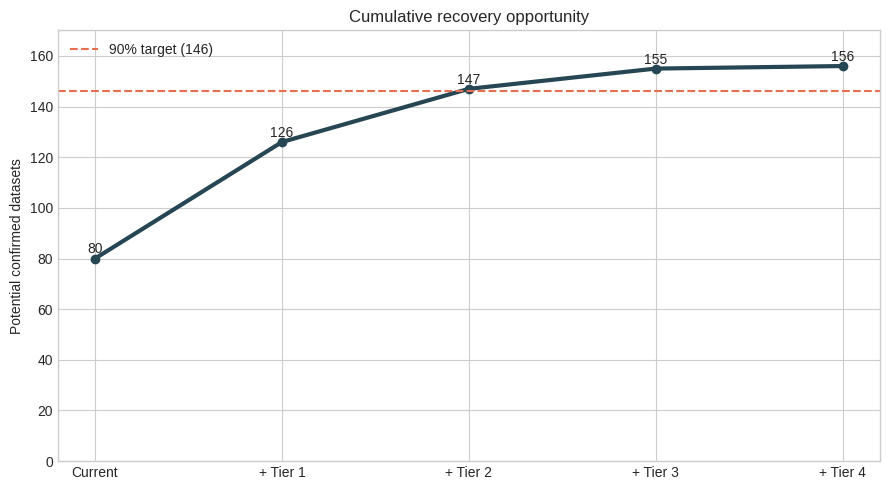

**Tier 1–2 opportunity: 67 datasets. Additional datasets needed for 90%: 66.**

,experiment_id,scope,failure_category,failure_subcategory,recovery_tier_label,recommended_solution,approx_frame_count
7,20250623_chem_35C_T02_1204,Keyence,Not previously attempted,Front half is complete; back half has not run,1 - Rerun or operational cleanup,Submit through the standard back-half array; r...,972.0
8,20250624_chem02_28C_T00_1356,Keyence,Not previously attempted,Front half is complete; back half has not run,1 - Rerun or operational cleanup,Submit through the standard back-half array; r...,1044.0
9,20250624_chem02_28C_T01_1808,Keyence,Not previously attempted,Front half is complete; back half has not run,1 - Rerun or operational cleanup,Submit through the standard back-half array; r...,1068.0
10,20250624_chem02_34C_T00_1243,Keyence,Not previously attempted,Front half is complete; back half has not run,1 - Rerun or operational cleanup,Submit through the standard back-half array; r...,960.0
11,20250624_chem02_34C_T01_1739,Keyence,Not previously attempted,Front half is complete; back half has not run,1 - Rerun or operational cleanup,Submit through the standard back-half array; r...,972.0
...,...,...,...,...,...,...,...
124,20260319,YX1,Join semantics,Death-stage lookup is unnecessarily embryo-spe...,2 - Small general code patch,Calculate stage from well/time acquisition met...,52920.0
115,20240314,YX1,Metadata dialect,Unmapped YX1 fluorescence channel,2 - Small general code patch,Add the explicit tested alias Celesta 473 -> GFP.,NaN
116,20251017_part2,YX1,Metadata dialect,Blank eighth plate-row label,2 - Small general code patch,When and only when there are exactly eight row...,95760.0
117,20251020,YX1,Metadata dialect,Blank eighth plate-row label,2 - Small general code patch,When and only when there are exactly eight row...,94392.0


In [ ]:
total = len(audit)
current = int(audit["confirmed_clean_latest_run"].sum())
target = math.ceil(0.90 * total)
tier_counts = (
    audit.loc[audit["confirmed_clean_latest_run"] == 0]
    .groupby("recovery_tier")["experiment_id"].nunique()
    .reindex([1, 2, 3, 4], fill_value=0)
)
cumulative = [current]
for tier in (1, 2, 3, 4):
    cumulative.append(cumulative[-1] + int(tier_counts[tier]))

labels = ["Current", "+ Tier 1", "+ Tier 2", "+ Tier 3", "+ Tier 4"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(labels, cumulative, marker="o", linewidth=3, color="#264653")
ax.axhline(target, color="#E76F51", linestyle="--", label=f"90% target ({target})")
ax.set_ylim(0, total * 1.05)
ax.set_ylabel("Potential confirmed datasets")
ax.set_title("Cumulative recovery opportunity")
ax.legend()
for i, value in enumerate(cumulative):
    ax.text(i, value + 2, str(value), ha="center")
plt.tight_layout()
plt.show()

easy = audit[
    (audit["confirmed_clean_latest_run"] == 0)
    & (audit["recovery_tier"].isin([1, 2]))
][[
    "experiment_id", "scope", "failure_category", "failure_subcategory",
    "recovery_tier_label", "recommended_solution", "approx_frame_count"
]].sort_values(["recovery_tier_label", "scope", "failure_category", "experiment_id"])
display(Markdown(f"**Tier 1–2 opportunity: {len(easy)} datasets. "
                 f"Additional datasets needed for 90%: {max(0, target-current)}.**"))
display(easy)

## Detailed failure-mode reference

### Not previously attempted: Front half is complete; back half has not run

**Affected:** 27 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `frame_detections`  
**Remediation state:** `ready_to_run`

**Recommended solution:** Submit through the standard back-half array; reuse validated front-half artifacts.

**Datasets:** 20250623_chem_35C_T02_1204, 20250624_chem02_28C_T00_1356, 20250624_chem02_28C_T01_1808, 20250624_chem02_34C_T00_1243, 20250624_chem02_34C_T01_1739, 20250624_chem02_35C_T00_1216, 20250624_chem02_35C_T01_1711, 20250625_chem02_28C_T02_1332, 20250625_chem02_34C_T02_1301, 20250625_chem02_35C_T02_1228, 20250703_chem3_28C_T00_1325, 20250703_chem3_34C_T00_1131, 20250703_chem3_34C_T01_1457, 20250703_chem3_35C_T00_1101, 20250703_chem3_35C_T01_1437, 20250716_chem4_28C_T00_1158, 20250716_chem4_28C_T01_1400, 20250716_chem4_34C_T00_1014, 20250716_chem4_35C_T00_1045, 20250721_chem5_28C_T00_1257, 20250721_chem5_28C_T01_1401, 20250721_chem5_35C_T00_1023, 20260319_cilia_crispant_18hpf, 20260319_cilia_crispant_24hpf, 20260319_cilia_crispant_30hpf, 20260416_cep290_30to48hpf_plate01_t02, 20260416_cep290_30to48hpf_plate02_t02

### Filesystem permissions: Snakemake work directory is not writable

**Affected:** 8 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `frame_detections`  
**Remediation state:** `operational_cleanup`

**Recommended solution:** Use a work-directory root owned by nlammers or repair group ownership/write permissions, then requeue.

**Datasets:** 20260326_wt_ref, 20260410_otx_pilot, 20260414_sci_b9d2_48hpf_plate01, 20260415_sci_cep290_48hpf_plate01, 20260417_irx_pilot, 20260418_irx_pilot, 20260501_zfpm_pilot, 20260502_zfpm_pilot

### Artifact compatibility: Pre-fix headerless empty snip inventory

**Affected:** 7 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `snip_processing`  
**Remediation state:** `fixed_in_head_needs_rerun`

**Recommended solution:** Current code emits a schemaful empty table and can quarantine the failed well. Rerun to complete the dataset; retry detection/segmentation separately only to recover that well's biological observations.

**Datasets:** 20250416, 20251104, 20251106, 20251113, 20260223, 20260224, 20260320

### Artifact compatibility: Pre-refactor QC/stage tables have stale schemas

**Affected:** 5 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `focus_qc`  
**Remediation state:** `rerun_needed`

**Recommended solution:** Invalidate and rebuild affected stage/QC products; add schema-version dependency for future automatic invalidation.

**Datasets:** 20250215, 20250305, 20250415, 20250416, 20250425

### Materialization geometry: Per-z-plane FLANN alignment

**Affected:** 4 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `materialization`  
**Remediation state:** `fixed_in_head_needs_rerun`

**Recommended solution:** Current code aligns once on the focus-stacked frame and reuses transforms. Force regeneration of affected Keyence z-stack products and rerun.

**Datasets:** 20260320_cilia_crispant_48hpf, 20260324_cep290_18hpf_24hpf_plate02, 20260324_cep290_18hpf_plate01, 20260414_b9d2_14hpf_plate02

### Developmental metadata: Missing start_age_hpf

**Affected:** 1 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `stage_predictions`  
**Remediation state:** `fixed_in_head_needs_rerun`

**Recommended solution:** Current code emits null predicted stage with missing_start_age_hpf status. Force stage/QC regeneration.

**Datasets:** 20260320_cilia_crispant_48hpf

### Developmental metadata: Missing temperature

**Affected:** 1 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `stage_predictions`  
**Remediation state:** `fixed_in_head_needs_rerun`

**Recommended solution:** Current code emits null predicted stage with missing_temperature status. Force stage/QC regeneration.

**Datasets:** 20250126

### Workflow state: Stale Snakemake lock

**Affected:** 1 datasets  
**Recovery tier:** 1 — 1 - Rerun or operational cleanup  
**Pipeline stage:** `frame_detections`  
**Remediation state:** `operational_cleanup`

**Recommended solution:** Confirm no live owner, run Snakemake --unlock for the experiment work directory, then requeue.

**Datasets:** 20240813_extras

### Join semantics: Death-stage lookup is unnecessarily embryo-specific

**Affected:** 7 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `death_detection`  
**Remediation state:** `code_change_needed`

**Recommended solution:** Calculate stage from well/time acquisition metadata independently of embryo/snip presence; preserve null/status behavior for missing age or temperature.

**Datasets:** 20251106, 20251121, 20251125, 20260213, 20260219, 20260319, 20260320

### Materialization geometry: Stitch master shape/size mismatch

**Affected:** 6 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `materialization`  
**Remediation state:** `code_change_needed`

**Recommended solution:** Normalize both metadata.shape and metadata.size before reloading master stitch parameters.

**Datasets:** 20250529_24hpf_ctrl_atf6, 20250529_24hpf_wfs1_ctcf, 20250529_30hpf_ctrl_atf6, 20250529_30hpf_wfs1_ctcf, 20250529_36hpf_ctrl_atf6, 20250529_36hpf_wfs1_ctcf

### Input eligibility: Abandoned/test paths included by recursive discovery

**Affected:** 4 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `metadata_ingest`  
**Remediation state:** `code_change_needed`

**Recommended solution:** Exclude path components such as ignore and other_files in one centralized Keyence source-eligibility policy.

**Datasets:** 20230830, 20231207, 20231208, 20240507

### Metadata dialect: Blank eighth plate-row label

**Affected:** 2 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `metadata_ingest`  
**Remediation state:** `code_change_needed`

**Recommended solution:** When and only when there are exactly eight rows with A-G followed by one blank, canonicalize the last label to H.

**Datasets:** 20251017_part2, 20251020

### Metadata dialect: Unmapped YX1 fluorescence channel

**Affected:** 1 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `metadata_ingest`  
**Remediation state:** `code_change_needed`

**Recommended solution:** Add the explicit tested alias Celesta 473 -> GFP.

**Datasets:** 20240314

### Orchestration race: Shared merged runtime config is written non-atomically

**Affected:** 1 datasets  
**Recovery tier:** 2 — 2 - Small general code patch  
**Pipeline stage:** `metadata_ingest`  
**Remediation state:** `code_change_needed`

**Recommended solution:** Use a per-experiment/run config path and finalize writes atomically with os.replace.

**Datasets:** 20260124

### Detection/segmentation: Headerless empty intermediate CSV

**Affected:** 7 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `snip_processing`  
**Remediation state:** `segmentation_retry_needed`

**Recommended solution:** Emit schemaful empty output, quarantine the well, and retry segmentation.

**Datasets:** 20250416, 20251104, 20251106, 20251113, 20260223, 20260224, 20260320

### Acquisition reconciliation: Same well was reacquired under a second XY position

**Affected:** 4 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `materialization`  
**Remediation state:** `data_reconciliation_needed`

**Recommended solution:** Choose the most complete acquisition, then the latest capture as tie-breaker; keep the losing source only in an audit artifact.

**Datasets:** 20260324_cep290_18hpf_24hpf_plate02, 20260324_cep290_18hpf_plate01, 20260331_b9d2_18hpf_plate01, 20260414_b9d2_14hpf_plate02

### Detection/segmentation: No retained prompt detections in well A10

**Affected:** 1 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `frame_detections`  
**Remediation state:** `segmentation_retry_needed`

**Recommended solution:** Retry detection with a controlled fallback; if it still fails, quarantine only A10 with an explicit no_valid_detection status.

**Datasets:** 20260320_cilia_crispant_48hpf

### QC robustness: Motion-blur QC receives a zero-pixel aligned mask

**Affected:** 1 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `motion_blur_qc`  
**Remediation state:** `well_quarantine_needed`

**Recommended solution:** Mark motion-blur QC not applicable for that snip/well, quarantine the invalid mask, and retry upstream segmentation if point recovery is required.

**Datasets:** 20260304

### Source corruption: Single zero-byte TIFF plane

**Affected:** 1 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `metadata_ingest`  
**Remediation state:** `data_recovery_needed`

**Recommended solution:** Quarantine the unavailable z-plane, retain remaining planes, and allow projection when the residual stack is sufficient.

**Datasets:** 20230608

### Truncated acquisition: ND2 padded with a zero-valued time-series tail

**Affected:** 1 datasets  
**Recovery tier:** 3 — 3 - Targeted data/model recovery  
**Pipeline stage:** `materialization`  
**Remediation state:** `data_recovery_needed`

**Recommended solution:** Trim each position's contiguous zero-valued terminal suffix and retain the 3,728 valid well-timepoints without padding.

**Datasets:** 20250520

### Unclassified runtime failure: Requires focused log review

**Affected:** 1 datasets  
**Recovery tier:** 4 — 4 - Diagnosis required  
**Pipeline stage:** `analysis_ready`  
**Remediation state:** `diagnosis_needed`

**Recommended solution:** Inspect the referenced latest stderr log and assign a stable failure category.

**Datasets:** 20240510

## Dataset-level reference

In [ ]:
reference_columns = [
    "experiment_id", "scope", "project_name", "pipeline_status",
    "pipeline_completion_fraction", "first_incomplete_stage",
    "approx_frame_count", "failure_category", "failure_subcategory",
    "latest_job_id", "latest_task_id", "latest_run_state",
    "recovery_tier_label", "recommended_solution", "failure_evidence_path",
]
display(audit.sort_values(
    ["scope", "confirmed_clean_latest_run", "recovery_tier", "experiment_id"]
)[reference_columns])

,experiment_id,scope,project_name,pipeline_status,pipeline_completion_fraction,first_incomplete_stage,approx_frame_count,failure_category,failure_subcategory,latest_job_id,latest_task_id,latest_run_state,recovery_tier_label,recommended_solution,failure_evidence_path
0,20230525,Keyence,Legacy / unspecified,back_half_failed,0.526,mask_geometry,136701.0,NaN,NaN,22857490,34,failed,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
1,20230831,Keyence,Legacy / unspecified,back_half_failed,0.737,stage_predictions,1600.0,NaN,NaN,22857490,43,failed,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
2,20250622_chem_35C_T00_1223_check,Keyence,Chemical perturbation,current_run_in_progress,0.053,materialization,1440.0,NaN,NaN,22857490,56,running_or_incomplete,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
3,20250622_chem_35C_T01_1605,Keyence,Chemical perturbation,current_run_in_progress,0.053,materialization,1152.0,NaN,NaN,22857490,57,running_or_incomplete,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
4,20250623_chem_28C_T02_1259,Keyence,Chemical perturbation,current_run_in_progress,0.053,materialization,1092.0,NaN,NaN,22857490,58,running_or_incomplete,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,20260206,YX1,Legacy / unspecified,complete_confirmed,1.000,NaN,144000.0,NaN,NaN,22656979,44,success,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
158,20260208,YX1,Legacy / unspecified,complete_confirmed,1.000,NaN,288900.0,NaN,NaN,22656979,45,success,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
159,20260210,YX1,Legacy / unspecified,complete_confirmed,1.000,NaN,122360.0,NaN,NaN,22656979,46,success,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
160,20260228,YX1,Legacy / unspecified,complete_confirmed,1.000,NaN,115968.0,NaN,NaN,22656979,51,success,Complete / none,NaN,/net/trapnell/vol1/home/nlammers/projects/repo...
